# TSP - Travelling Salesman Problem mediante uso de ACO
**Grupo 3 - Inteligencia Artificial USFQ**

Integrantes: Lucy Barreno, Ana Haro, Darwin Simba, Jhon Del Castillo

## Algoritmo: Ant Colony Optimization (ACO) para TSP

Para más ciudades, los algoritmos exactos (como Held-Karp) crecen exponencialmente.
Esta metaheurística, basada en Dorigo et al. (2006), simula el comportamiento de
colonias de hormigas para encontrar rutas de bajo costo:

1. **Inicialización**: se asigna una feromona uniforme τ₀ a todas las aristas y se
   precalcula la heurística η = 1/d para cada par de ciudades.
2. **Construcción de rutas**: cada hormiga parte de una ciudad aleatoria y elige la
   siguiente ciudad según la regla probabilística P(i→j) = (τᵢⱼᵅ · ηᵢⱼᵝ) / Σ,
   usando una lista tabú para no repetir ciudades (ciclo hamiltoniano válido).
3. **Evaluación**: se calcula la distancia total de cada ruta construida.
4. **Actualización de feromonas**: se aplica evaporación τ ← (1-ρ)·τ y luego
   depósito Δτ = Q/L por cada hormiga, reforzando las aristas de rutas más cortas.
5. **Criterio de parada**: se repiten los pasos 2-4 durante `num_iterations`
   iteraciones, guardando siempre la mejor solución global encontrada.

No garantiza el óptimo global, pero produce rutas de alta calidad en tiempos
computacionales bajos, especialmente para instancias medianas del TSP.

Parámetros clave:
- alpha (α): influencia de las feromonas. Alto → explotación de rutas conocidas.
- beta (β):  influencia de la heurística 1/d. Alto → preferencia por aristas cortas.
- evaporation_rate (ρ): tasa de evaporación. Alto → mayor exploración.
- q (Q): constante de depósito de feromonas (escalar según distancias del problema).

Mejor ruta encontrada: [5, 1, 0, 7, 2, 4, 3, 6]
Distancia total: 29.769


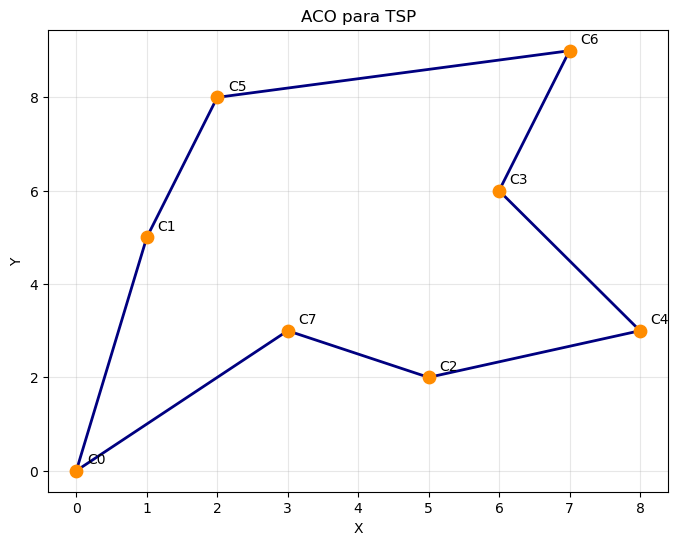

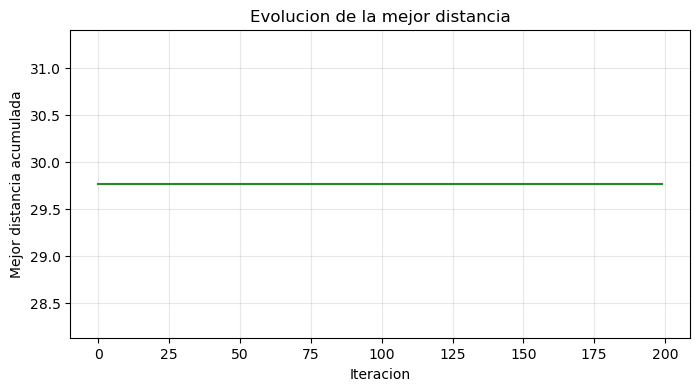

In [1]:
import numpy as np
import matplotlib.pyplot as plt

class ACOForTSP:

    def __init__(
        self,
        coordinates,
        num_ants=20,
        num_iterations=150,
        alpha=1.0,
        beta=3.0,
        evaporation_rate=0.5,
        q=100.0,
        seed=123,
    ):

        self.coordinates = np.asarray(coordinates, dtype=float)
        self.num_cities = len(self.coordinates)
        self.num_ants = num_ants
        self.num_iterations = num_iterations
        self.alpha = alpha
        self.beta = beta
        self.evaporation_rate = evaporation_rate
        self.q = q
        self.random = np.random.default_rng(seed)

        self.distance_matrix = self._build_distance_matrix()
        self.pheromone_matrix = np.ones((self.num_cities, self.num_cities), dtype=float)
        self.best_route = None
        self.best_distance = np.inf
        self.history = []



    def _build_distance_matrix(self):
        distance_matrix = np.zeros((self.num_cities, self.num_cities), dtype=float)
        for i in range(self.num_cities):
            for j in range(self.num_cities):
                if i == j:
                    continue
                distance_matrix[i, j] = np.linalg.norm(self.coordinates[i] - self.coordinates[j])
        return distance_matrix

    def _route_distance(self, route):
        distance = 0.0
        for i in range(self.num_cities):
            origin = route[i]
            destination = route[(i + 1) % self.num_cities]
            distance += self.distance_matrix[origin, destination]
        return distance



    def _choose_next_city(self, current_city, unvisited):
        unvisited = np.array(list(unvisited))
        pheromones = self.pheromone_matrix[current_city, unvisited] ** self.alpha
        distances = self.distance_matrix[current_city, unvisited]
        heuristic = (1.0 / np.maximum(distances, 1e-10)) ** self.beta
        probabilities = pheromones * heuristic
        probabilities_sum = probabilities.sum()

        if probabilities_sum == 0:
            return int(self.random.choice(unvisited))

        probabilities = probabilities / probabilities_sum
        return int(self.random.choice(unvisited, p=probabilities))

    def _build_route(self, start_city=None):
        if start_city is None:
            start_city = int(self.random.integers(0, self.num_cities))

        route = [start_city]
        unvisited = set(range(self.num_cities))
        unvisited.remove(start_city)
        current_city = start_city

        while unvisited:
            next_city = self._choose_next_city(current_city, unvisited)
            route.append(next_city)
            unvisited.remove(next_city)
            current_city = next_city
        return route

    def _evaporate_pheromones(self):
        self.pheromone_matrix *= 1.0 - self.evaporation_rate
        self.pheromone_matrix = np.maximum(self.pheromone_matrix, 1e-10)

    def _deposit_pheromones(self, routes, distances):
        for route, distance in zip(routes, distances):
            contribution = self.q / max(distance, 1e-10)
            for i in range(self.num_cities):
                origin = route[i]
                destination = route[(i + 1) % self.num_cities]
                self.pheromone_matrix[origin, destination] += contribution
                self.pheromone_matrix[destination, origin] += contribution

    def solve(self):
        for _ in range(self.num_iterations):
            iteration_routes = []
            iteration_distances = []

            for _ in range(self.num_ants):
                route = self._build_route()
                distance = self._route_distance(route)
                iteration_routes.append(route)
                iteration_distances.append(distance)

                if distance < self.best_distance:
                    self.best_route = route.copy()
                    self.best_distance = distance

            self._evaporate_pheromones()
            self._deposit_pheromones(iteration_routes, iteration_distances)
            self.history.append(self.best_distance)
        return self.best_route, self.best_distance

def plot_tsp_route(coordinates, route, title):
    coordinates = np.asarray(coordinates)
    ordered_coordinates = coordinates[route + [route[0]]]
    plt.figure(figsize=(8, 6))
    plt.scatter(coordinates[:, 0], coordinates[:, 1], color='darkorange', s=80, zorder=3)
    plt.plot(ordered_coordinates[:, 0], ordered_coordinates[:, 1], color='navy', linewidth=2)


    for index, (x_coord, y_coord) in enumerate(coordinates):
        plt.text(x_coord + 0.15, y_coord + 0.15, f'C{index}', fontsize=10)

    plt.title(title)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True, alpha=0.3)
    plt.show()

def study_case_tsp():
    coordinates = [
        (0, 0),
        (1, 5),
        (5, 2),
        (6, 6),
        (8, 3),
        (2, 8),
        (7, 9),
        (3, 3),
    ]

    aco_tsp = ACOForTSP(
        coordinates=coordinates,
        num_ants=25,
        num_iterations=200,
        alpha=1.0,
        beta=4.0,
        evaporation_rate=0.4,
        q=120.0,
        seed=42,
    )

    best_route, best_distance = aco_tsp.solve()
    print('Mejor ruta encontrada:', best_route)
    print(f'Distancia total: {best_distance:.3f}')

    plot_tsp_route(np.array(coordinates), best_route, 'ACO para TSP')
    plt.figure(figsize=(8, 4))
    plt.plot(aco_tsp.history, color='forestgreen')
    plt.title('Evolucion de la mejor distancia')
    plt.xlabel('Iteracion')
    plt.ylabel('Mejor distancia acumulada')
    plt.grid(True, alpha=0.3)
    plt.show()

study_case_tsp()


## Conclusiones

### Sobre el problema
El TSP es un problema de optimización combinatoria con complejidad factorial. Con 8
ciudades existen 2.520 rutas posibles (7!/2), lo que permite al ACO encontrar soluciones
de alta calidad en pocas iteraciones. La representación utilizada es un **grafo completo
ponderado**, donde cada nodo es una ciudad y cada arista tiene como peso la distancia
euclidiana entre dos ciudades, calculada con la norma L2.

### Sobre el algoritmo utilizado
El **Ant Colony Optimization (ACO)** basado en Dorigo et al. (2006) demostró ser efectivo:
- El enjambre de 25 hormigas construyó soluciones diversas en paralelo, explorando
  distintas regiones del espacio de búsqueda en cada iteración
- El mecanismo de feromonas permitió que el conocimiento colectivo convergiera
  progresivamente hacia rutas de menor costo, sin necesidad de búsqueda local adicional
- Con β=4.0, las hormigas priorizaron fuertemente las aristas cortas, acelerando la
  convergencia inicial en un problema de escala reducida

### Sobre los parámetros
- **α=1.0 / β=4.0**: el peso alto de la heurística (1/d) guía eficientemente la
  búsqueda en instancias pequeñas, donde las aristas cortas suelen pertenecer a la
  solución óptima
- **ρ=0.4**: la evaporación moderada permitió que los rastros persistan lo suficiente
  para reforzar buenas soluciones sin estancar la exploración
- **Q=120**: el depósito proporcional a Q/distancia garantizó que las rutas más cortas
  recibieran mayor refuerzo, acelerando la convergencia del enjambre

### Sobre la dificultad
- La principal dificultad del ACO es la **sensibilidad a los parámetros**: una mala
  configuración de α, β o ρ puede llevar a convergencia prematura en óptimos locales